# Do the Hello World example on a 2-qubit Bell state

## Step 1: Map the problem to circuits & operators

In [20]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli

import matplotlib.pyplot as plt
from qiskit_aer.primitives import Estimator

from qiskit.quantum_info import SparsePauliOp

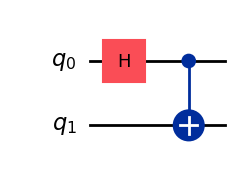

In [6]:
# Map problem to circuit:
qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

qc.draw("mpl")

**Multiple-qb (ZZ, HX) operators (ops) should have non-zero expectation values (EVs) & single-qb (IX or HI) ops will have 0 EVs on |phi+>

In [7]:
# Map problem to operators:

ZZ = Pauli("ZZ")
ZI = Pauli("ZI")
IZ = Pauli("IZ")

XX = Pauli("XX")
XI = Pauli("XI")
IX = Pauli("IX")

observables = [ZZ, ZI, IZ, XX, XI, IX]

## Step 2: Optimize the circuit's observables

## Step 3: Execute on the backend

In [8]:
# estimator = Estimator(approximation=True) --> To get the exact values devoid of shot noise.
estimator = Estimator()

job = estimator.run([qc] * len(observables), observables)

job.result()

EstimatorResult(values=array([ 1.        , -0.015625  , -0.015625  ,  1.        ,  0.00585938,
        0.00585938]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0065201, 'sample_measure_time': 0.0037439, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 16264, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 4, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.999755859375, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0065201, 'sample_measure_time': 0.0037439, 

## Step 4: Post-processing (& plotting)

Not much p-p to do, Estimator handled it automatically.

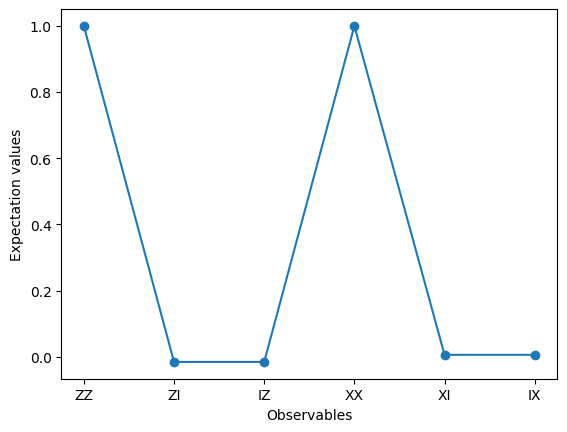

In [9]:
# Plot the EVs for a 2-qb entangled state:
data = ["ZZ", "ZI", "IZ", "XX", "XI", "IX"]
values = job.result().values

plt.plot(data, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Expectation values")
plt.show()

## Extend the Hello World example to an $n$-qubit GHZ state

## Step 1: Map the problem to circuits & operators

Make a circuit for any value of **n** that we want.

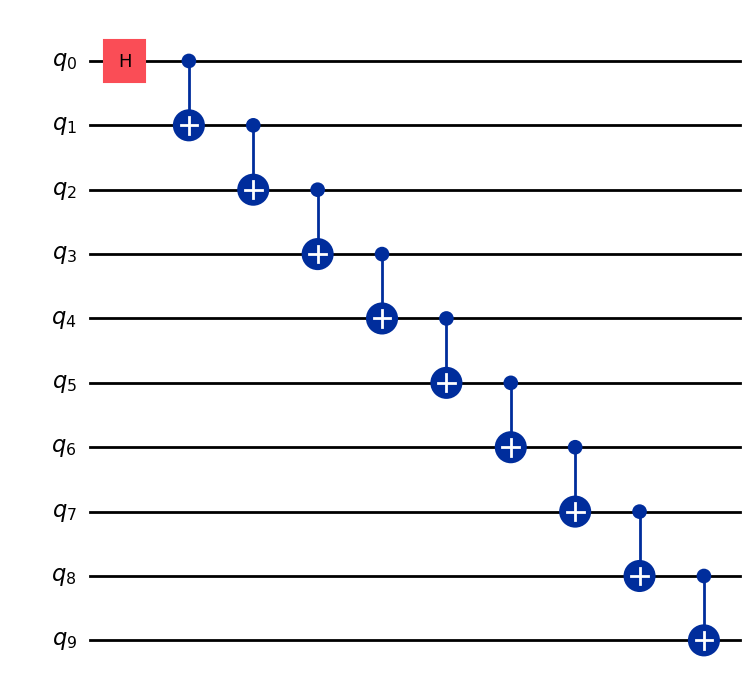

In [18]:
def get_qc_for_n_qubit_GHZ_state(n):
    qc = QuantumCircuit(n)   # no. of registers.
    qc.h(0)  # Apply Hd. to state |0>
    # For the rest of the qbs, apply a ladder of CNOT gates to get GHZ form
    for i in range(n-1):
        qc.cx(i, i+1)   # 1st index, then 2nd.
    return qc

n = 10
qc = get_qc_for_n_qubit_GHZ_state(n)

qc.draw(output="mpl")
    

* For n = 4 (an example)
Start: |0000⟩
After qc.h(0):

**1/sqrt(2) (∣0000⟩ + ∣1000⟩)**

After qc.cx(0,1) (control=q0, target=q1 — flips q1 only when q0=1):

|0000⟩ → q0=0, untouched → |0000⟩
|1000⟩ → q0=1, flips q1 → |1100⟩

**1/sqrt(2) (∣0000⟩ + ∣1100⟩)** etc 

___
Noise increases the further away qbs are.

Create oprs that allow us to probe this inc. in distance & how EV is corrupted by it.

In [21]:
operator_strings = ["Z" + "I" * i + "Z" + "I" * (n-2-i) for i in range(n-1)]
print(operator_strings)
print(len(operator_strings))

operators = [SparsePauliOp(operator_string) for operator_string in operator_strings]

['ZZIIIIIIII', 'ZIZIIIIIII', 'ZIIZIIIIII', 'ZIIIZIIIII', 'ZIIIIZIIII', 'ZIIIIIZIII', 'ZIIIIIIZII', 'ZIIIIIIIZI', 'ZIIIIIIIIZ']
9
